In [10]:
import numpy as np
import math as m

def altintas_zero_order_directional_matrix(a, N, phi_st, phi_ex, Ktc, Krc):
    """
    Returns A (2x2) such that: F_reg = A @ (x(t) - x(t-tau))
    (this is the averaged / zero-order displacement-linear directional matrix).
    """
    C = (N * a) / (8.0 * m.pi)

    dphi   = phi_ex - phi_st
    dsin2p = m.sin(2.0 * phi_ex) - m.sin(2.0 * phi_st)
    dcos2p = m.cos(2.0 * phi_ex) - m.cos(2.0 * phi_st)

    Axx = C * ( Ktc * (2.0*dphi - dsin2p) + Krc * dcos2p )
    Axy = C * ( Ktc * dcos2p - Krc * (2.0*dphi - dsin2p) )
    Ayx = -Axy
    Ayy =  Axx

    return np.array([[Axx, Axy],
                     [Ayx, Ayy]], dtype=float)

# Entry and exit Angles for downmilling
def compute_entry_exit_angles_downmilling_steady(b: float, D: float):
    # Current tool entry / exit angles: --> https://www.sciencedirect.com/science/article/pii/S0888327020307044#b0160
    arg = np.clip(1.0 - (2.0 * b / D), -1.0, 1.0)
    phi_st = np.pi - np.arccos(arg)
    phi_ex = np.pi
    return phi_st, phi_ex



In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# --- System matrices (SI units) ---
M = np.array([[215.0, -20.0],
              [-20.0, 150.0]], dtype=float)

C = np.array([[2000.0,    0.0],
              [   0.0, 1000.0]], dtype=float)

K = np.array([[4.21e6,   0.0],
              [  0.0, 4.61e6]], dtype=float)

def load_macro_from_npz(npz_path, axes=(0, 1)):
    data = np.load(npz_path, allow_pickle=False)

    Lambda = data["Lambda_xyz"]  # (3,3)
    Dx     = data["Dx_xyz"]      # (3,3)
    Kx     = data["Kx_xyz"]      # (3,3)

    a0, a1 = axes

    M2 = Lambda[np.ix_([a0, a1], [a0, a1])]
    C2 = Dx[np.ix_([a0, a1], [a0, a1])]
    K2 = Kx[np.ix_([a0, a1], [a0, a1])]

    extras = {k: data[k] for k in data.files if k not in ["Lambda_xyz", "Dx_xyz", "Kx_xyz"]}
    return M2, C2, K2, extras

# M2, C2, K2, extras = load_macro_from_npz("./data/linearized_operational_space_xyz.npz", axes=(0, 1))  # (x,y)
# M = M2
# C = C2
# K = K2


# --- Attached mass (not used in G(s) yet) ---
M_micro = np.diag([100.0, 100.0])  # kg

Z = np.zeros((2,2))
I = np.eye(2)
Minv = np.linalg.inv(M + M_micro)

A = np.block([
    [Z, I],
    [-Minv @ K, -Minv @ C]
])

eigvals = np.linalg.eigvals(A)

def build_second_order_ss(M, C, K):
    """
    Convert: M xdd + C xd + K x = 0  (n=2)  to
    z = [x; xd] in R^4,   zdot = A z
    """
    I = np.eye(2)
    Z = np.zeros((2,2))
    Minv = np.linalg.inv(M)

    A = np.block([
        [Z, I],
        [-Minv @ K, -Minv @ C]
    ])
    return A


# ============================================================
# 1) Rigidly attached point mass (fixed offset p0; pure translation)
# ============================================================

def build_attached_mass_model(M, C, K, M_micro):
    M_tot = M + M_micro
    A = build_second_order_ss(M_tot, C, K)
    return A, M_tot

A_stiff, _ = build_attached_mass_model(M, C, K, M_micro)

def delayed_x(t_query, t_hist, x_hist):
    """
    Linear interpolation of x at time t_query using stored history.
    Assumes t_hist is increasing and x_hist has matching length.
    """
    if t_query <= t_hist[0]:
        return x_hist[0].copy()
    if t_query >= t_hist[-1]:
        return x_hist[-1].copy()

    # Find right index i such that t_hist[i-1] <= t_query < t_hist[i]
    i = np.searchsorted(t_hist, t_query)
    t0, t1 = t_hist[i-1], t_hist[i]
    x0, x1 = x_hist[i-1], x_hist[i]
    w = (t_query - t0) / (t1 - t0)
    return (1.0 - w) * x0 + w * x1






Spindle freq     = 133.33 Hz
Tooth freq       = 533.33 Hz
Regenerative tau = 1.875000e-03 s


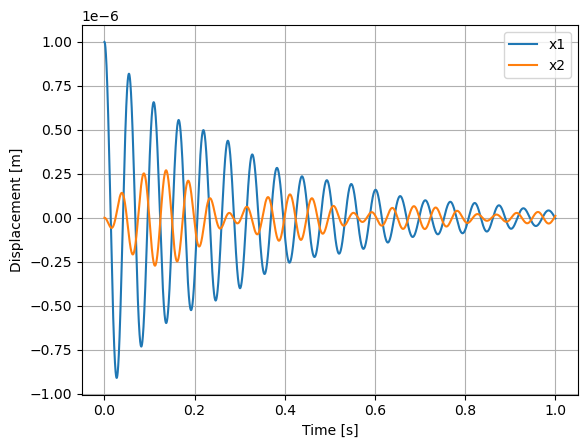

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) Define the 2-DOF plant
# ----------------------------
M = np.array([[215.0, -20.0],
              [-20.0, 150.0]], dtype=float)

C = np.array([[2000.0,    0.0],
              [   0.0, 1000.0]], dtype=float)

K = np.array([[4.21e6,   0.0],
              [  0.0, 4.61e6]], dtype=float)

M_micro = np.diag([100.0, 100.0])
M_tot = M + M_micro
Minv  = np.linalg.inv(M_tot)

# ----------------------------
# 2) Regenerative cutting model
# ----------------------------
tau = 0.1  # s (your current setting)


# milling parameters you must set (example placeholders)
a   = 0.005      # axial depth [m] (be consistent with Ktc/Krc units!)
N_t = 2          # number of teeth (Altintas N in your formula)
phi_st = np.pi/2    # entry angle [rad]
phi_ex = np.pi   # exit angle [rad]

# ----------------------------
# Spindle / tooth passing delay
# ----------------------------
rpm = 8000.0
N_t = 4 # number of teeth

f_rev   = rpm / 60.0                 # spindle frequency [Hz]
f_tooth = f_rev * N_t                # tooth passing frequency [Hz]
tau     = 1.0 / f_tooth              # regenerative delay [s]

print(f"Spindle freq     = {f_rev:.2f} Hz")
print(f"Tooth freq       = {f_tooth:.2f} Hz")
print(f"Regenerative tau = {tau:.6e} s")

Ktc = 1930.4 # N/mm
Krc = 1159.6 # N/mm
Kt = Ktc # N/mm
Kr = Krc / Ktc # N/mm

b = 0.005 # radial depth [m]
D = 0.1   # tool diameter [m]

phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(b, D)

A_cut_dir = altintas_zero_order_directional_matrix(
    a=a, N=N_t, phi_st=phi_st, phi_ex=phi_ex, Ktc=Ktc, Krc=Krc
)


# ----------------------------
# 3) RHS without expensive history objects
# ----------------------------
def rhs_regen_fast(z, x_tau, A_cut_dir, Minv, C, K):
    """
    z = [x; v], x_tau is delayed displacement vector.
    """
    x = z[:2]
    v = z[2:]

    F_cut = A_cut_dir @ (x - x_tau)
    xdd   = Minv @ (F_cut - C @ v - K @ x)

    dz = np.empty_like(z)
    dz[:2] = v
    dz[2:] = xdd
    return dz

# ----------------------------
# 4) Efficient delay access using ring buffer
# ----------------------------
class DelayBuffer:
    """
    Fixed-step delay buffer for x(t) with linear interpolation for x(t - tau).
    Assumes constant dt.
    """
    def __init__(self, tau, dt, x0):
        self.dt = float(dt)
        self.tau = float(tau)

        # tau = k*dt + alpha*dt, alpha in [0,1)
        k_float = self.tau / self.dt
        self.k = int(np.floor(k_float))
        self.alpha = k_float - self.k

        # Need at least k+2 samples to interpolate safely
        self.L = self.k + 2

        self.buf = np.zeros((self.L, 2), dtype=float)

        # Initialize history x(t) = x0 for t in [-tau, 0]
        self.buf[:] = x0

        # write pointer: points to "current time sample index"
        # We'll treat buf[ptr] as x at current step.
        self.ptr = 0

    def push(self, x_new):
        """Store x at the new time step."""
        self.ptr = (self.ptr + 1) % self.L
        self.buf[self.ptr] = x_new

    def get_delayed(self):
        """
        Return x(t - tau) using linear interpolation:
        x_tau ≈ (1-alpha)*x[n-k] + alpha*x[n-k-1]
        (depending on indexing convention).
        """
        # Current sample is at self.ptr (time t_n)
        # We want t_n - tau = t_{n-k-alpha}.

        # x_{n-k} is k steps back:
        idx1 = (self.ptr - self.k) % self.L
        idx2 = (self.ptr - self.k - 1) % self.L

        # Interpolate between the two samples
        # If alpha=0 => exactly idx1
        return (1.0 - self.alpha) * self.buf[idx1] + self.alpha * self.buf[idx2]

# ----------------------------
# 5) RK4 step that calls delayed state cheaply
# ----------------------------
def rk4_step_fast(z, dt, delaybuf, A_cut_dir, Minv, C, K):
    # For intermediate RK stages, we approximate x_tau using the *same* delayed value
    # from the current buffer state (common approach for explicit RK on DDEs).
    x_tau = delaybuf.get_delayed()

    k1 = rhs_regen_fast(z,               x_tau, A_cut_dir, Minv, C, K)
    k2 = rhs_regen_fast(z + 0.5*dt*k1,   x_tau, A_cut_dir, Minv, C, K)
    k3 = rhs_regen_fast(z + 0.5*dt*k2,   x_tau, A_cut_dir, Minv, C, K)
    k4 = rhs_regen_fast(z + dt*k3,       x_tau, A_cut_dir, Minv, C, K)
    return z + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# ----------------------------
# 6) Simulate
# ----------------------------
T  = 1.0
dt = 1e-5
N  = int(T/dt) + 1
t  = np.linspace(0.0, T, N)

z = np.zeros((N, 4), dtype=float)
z[0, 0] = 1e-6  # small perturbation

# Initialize delay buffer with x0
delaybuf = DelayBuffer(tau=tau, dt=dt, x0=z[0, :2].copy())

# Optional early-stop
y0 = np.linalg.norm(z[0, :2])
y_limit = max(1e-12, 1e3*y0)
stop_k = None

for k in range(N-1):
    z_next = rk4_step_fast(z[k], dt, delaybuf, A_cut_dir, Minv, C, K)
    z[k+1] = z_next

    # push new x into delay buffer
    delaybuf.push(z_next[:2])

    # early stop (optional)
    y = np.linalg.norm(z_next[:2])
    if not np.all(np.isfinite(z_next)):
        stop_k = k+1
        print(f"Stopped: NaN/Inf at t={t[stop_k]:.6f}s")
        break
    if y > y_limit:
        stop_k = k+1
        print(f"Stopped: amplitude exceeded {y_limit:.3e} at t={t[stop_k]:.6f}s")
        break

if stop_k is not None:
    t = t[:stop_k+1]
    z = z[:stop_k+1]

x = z[:, :2]

# ----------------------------
# 7) Plot
# ----------------------------
plt.figure()
plt.plot(t, x[:, 0], label="x1")
plt.plot(t, x[:, 1], label="x2")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True)
plt.legend()
plt.show()

median(rk) = 0.994612
classification = STABLE (decay)
log-envelope slope alpha = -3.008234e+00  [1/s] (alpha>0 growing)


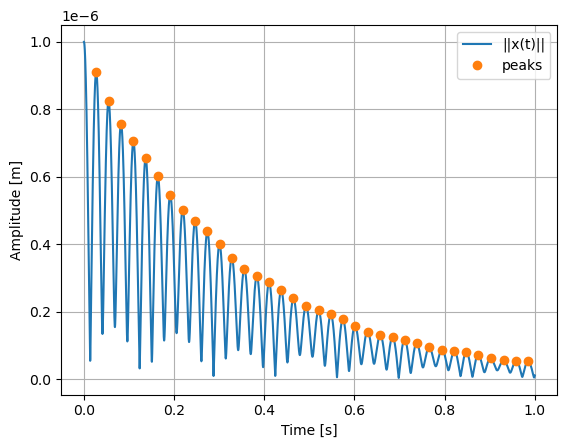

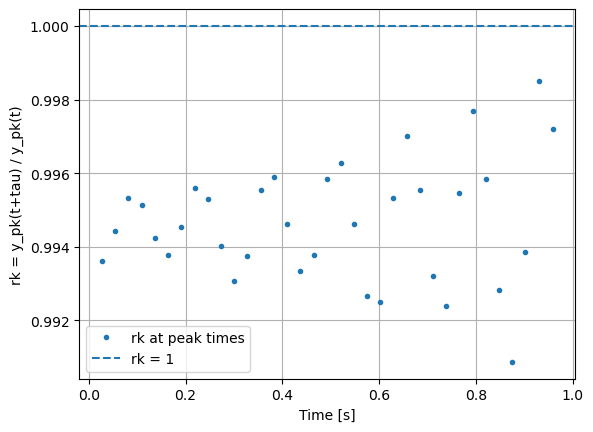

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Heuristic stability analysis
# ----------------------------

def amplitude_norm(x):
    """y(t) = ||x(t)||2 for x shape (N,2)."""
    x = np.asarray(x)
    return np.sqrt(np.sum(x*x, axis=1))

def find_peaks_simple(y, min_distance=1):
    """
    Simple peak finder:
    indices i where y[i-1] < y[i] >= y[i+1].
    Enforces a minimum spacing (in samples) between peaks.
    """
    y = np.asarray(y)
    N = len(y)
    cand = np.where((y[1:-1] > y[:-2]) & (y[1:-1] >= y[2:]))[0] + 1
    if len(cand) == 0:
        return cand

    if min_distance <= 1:
        return cand

    # Greedy selection by peak height
    order = np.argsort(y[cand])[::-1]
    selected = []
    taken = np.zeros(N, dtype=bool)
    for idx in cand[order]:
        if not taken[idx]:
            selected.append(idx)
            lo = max(0, idx - min_distance)
            hi = min(N, idx + min_distance + 1)
            taken[lo:hi] = True
    return np.array(sorted(selected))

def peak_ratio_median(t, x, tau, peak_min_distance_s=None, imag_tol=None):
    """
    Compute median r_k = y_pk(t+tau)/y_pk(t) using peak envelope.
    Returns: median_rk, rk array, peak times/vals, used times.
    """
    t = np.asarray(t)
    y = amplitude_norm(np.asarray(x))
    dt = float(np.median(np.diff(t)))

    # Default peak spacing: avoid detecting tiny ripples as peaks.
    # tau/4 is a decent heuristic; increase if too many peaks are detected.
    if peak_min_distance_s is None:
        peak_min_distance_s = max(2*dt, tau/4.0)

    min_dist_samples = max(1, int(round(peak_min_distance_s / dt)))
    pk_idx = find_peaks_simple(y, min_distance=min_dist_samples)

    if len(pk_idx) < 5:
        return np.nan, np.array([]), np.array([]), np.array([]), np.array([])

    tpk = t[pk_idx]
    ypk = y[pk_idx]

    # Envelope interpolant based on peak points
    def ypk_at(tq):
        return np.interp(tq, tpk, ypk)

    valid = (tpk + tau <= tpk[-1])
    t_use = tpk[valid]
    if len(t_use) < 5:
        return np.nan, np.array([]), tpk, ypk, np.array([])

    y1 = ypk_at(t_use)
    y2 = ypk_at(t_use + tau)

    eps = 1e-30
    rk = y2 / np.maximum(y1, eps)

    med = float(np.median(rk))
    return med, rk, tpk, ypk, t_use

def classify_from_median_rk(median_rk, tol=0.02):
    """
    tol = 0.02 means ±2% band around 1.0.
    """
    if not np.isfinite(median_rk):
        return "unknown (insufficient peaks / invalid)"
    if median_rk > 1.0 + tol:
        return "UNSTABLE (growth)"
    if median_rk < 1.0 - tol:
        return "STABLE (decay)"
    return "MARGINAL (~boundary)"

def log_env_slope(tpk, ypk, t_min=0.1, t_max=None):
    """
    Fit log(ypk) ~ alpha*t + b over peaks in [t_min, t_max].
    alpha > 0 => exponential growth; alpha < 0 => decay.
    """
    tpk = np.asarray(tpk); ypk = np.asarray(ypk)
    if t_max is None:
        t_max = float(tpk[-1])
    mask = (tpk >= t_min) & (tpk <= t_max) & (ypk > 0)
    tt = tpk[mask]
    yy = ypk[mask]
    if len(tt) < 5:
        return np.nan
    A = np.vstack([tt, np.ones_like(tt)]).T
    alpha, _ = np.linalg.lstsq(A, np.log(yy), rcond=None)[0]
    return float(alpha)

# Run heuristic on your simulated output:
y = amplitude_norm(x)
median_rk, rk, tpk, ypk, t_use = peak_ratio_median(t, x, tau, peak_min_distance_s=tau/4)

cls = classify_from_median_rk(median_rk, tol=0.02 * 1e-6)
alpha = log_env_slope(tpk, ypk, t_min=0.1)

print(f"median(rk) = {median_rk:.6f}")
print(f"classification = {cls}")
print(f"log-envelope slope alpha = {alpha:.6e}  [1/s] (alpha>0 growing)")

# Optional plots: peaks + rk sequence
plt.figure()
plt.plot(t, y, label="||x(t)||")
if len(tpk) > 0:
    plt.plot(tpk, ypk, "o", label="peaks")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [m]")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
if len(rk) > 0:
    plt.plot(t_use, rk, ".", label="rk at peak times")
    plt.axhline(1.0, linestyle="--", label="rk = 1")
plt.xlabel("Time [s]")
plt.ylabel("rk = y_pk(t+tau) / y_pk(t)")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

# ============================================================
# 0) Plant (SI units)
# ============================================================
M = np.array([[215.0, -20.0],
              [-20.0, 150.0]], dtype=float)

C = np.array([[2000.0,    0.0],
              [   0.0, 1000.0]], dtype=float)

K = np.array([[4.21e6,   0.0],
              [  0.0, 4.61e6]], dtype=float)

M_micro = np.diag([100.0, 100.0])  # kg
M_tot = M + M_micro
Minv  = np.linalg.inv(M_tot)

# ============================================================
# 1) Milling geometry: entry/exit angles for downmilling
# ============================================================
def compute_entry_exit_angles_downmilling_steady(b: float, D: float):
    # Ensure physical bounds
    b = np.clip(b, 0.0, D)
    arg = np.clip(1.0 - (2.0 * b / D), -1.0, 1.0)
    phi_st = np.pi - np.arccos(arg)
    phi_ex = np.pi
    return float(phi_st), float(phi_ex)

# ============================================================
# 2) Altintas zero-order (averaged) regenerative directional matrix
#    Returns A (2x2) such that F_reg = A @ (x(t) - x(t - tau))
# ============================================================
def altintas_zero_order_directional_matrix(a, N, phi_st, phi_ex, Ktc, Krc):
    """
    a: axial depth [m]
    N: number of teeth
    phi_st, phi_ex: entry/exit [rad]
    Ktc, Krc: cutting coeffs [N/m^2] (or consistent; see conversion below)
    """
    Cc = (N * a) / (8.0 * m.pi)

    dphi   = phi_ex - phi_st
    dsin2p = m.sin(2.0 * phi_ex) - m.sin(2.0 * phi_st)
    dcos2p = m.cos(2.0 * phi_ex) - m.cos(2.0 * phi_st)

    Axx = Cc * ( Ktc * (2.0*dphi - dsin2p) + Krc * dcos2p )
    Axy = Cc * ( Ktc * dcos2p - Krc * (2.0*dphi - dsin2p) )
    Ayx = -Axy
    Ayy =  Axx

    return np.array([[Axx, Axy],
                     [Ayx, Ayy]], dtype=float)

# ============================================================
# 3) Rotation: A(theta) = R^T A0 R
# ============================================================
def rot2(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]], dtype=float)

def rotate_A(A0, theta):
    R = rot2(theta)
    return R.T @ A0 @ R

# ============================================================
# 4) Efficient fixed-step delay buffer (ring buffer)
# ============================================================
class DelayBuffer:
    def __init__(self, tau, dt, x0):
        self.dt = float(dt)
        self.tau = float(tau)

        k_float = self.tau / self.dt
        self.k = int(np.floor(k_float))
        self.alpha = k_float - self.k

        self.L = self.k + 2  # enough for linear interpolation
        self.buf = np.zeros((self.L, 2), dtype=float)
        self.buf[:] = x0
        self.ptr = 0

    def push(self, x_new):
        self.ptr = (self.ptr + 1) % self.L
        self.buf[self.ptr] = x_new

    def get_delayed(self):
        idx1 = (self.ptr - self.k) % self.L
        idx2 = (self.ptr - self.k - 1) % self.L
        return (1.0 - self.alpha) * self.buf[idx1] + self.alpha * self.buf[idx2]

# ============================================================
# 5) Dynamics + RK4 (using one delayed sample per step)
# ============================================================
def rhs_regen(z, x_tau, A_cut_dir, Minv, C, K):
    x = z[:2]
    v = z[2:]
    F_cut = A_cut_dir @ (x - x_tau)
    xdd = Minv @ (F_cut - C @ v - K @ x)
    dz = np.empty_like(z)
    dz[:2] = v
    dz[2:] = xdd
    return dz

def rk4_step(z, dt, delaybuf, A_cut_dir, Minv, C, K):
    x_tau = delaybuf.get_delayed()
    k1 = rhs_regen(z,               x_tau, A_cut_dir, Minv, C, K)
    k2 = rhs_regen(z + 0.5*dt*k1,   x_tau, A_cut_dir, Minv, C, K)
    k3 = rhs_regen(z + 0.5*dt*k2,   x_tau, A_cut_dir, Minv, C, K)
    k4 = rhs_regen(z + dt*k3,       x_tau, A_cut_dir, Minv, C, K)
    return z + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# ============================================================
# 6) Heuristic stability test for a given (A_cut_dir, tau)
#    - run for a short time
#    - estimate growth rate alpha from log(||x||)
#    - early stop if it explodes
# ============================================================
def simulate_and_classify(A_cut_dir, tau, dt=2e-5, T=None,
                          x0=np.array([1e-6, 0.0]),
                          growth_alpha_thresh=5.0,  # 1/s ; tune
                          explode_factor=1e4,
                          abs_limit=1e-2):
    """
    Returns: stable_bool, alpha_est, t_end
    """
    if T is None:
        # enough cycles of the delay to observe growth/decay
        T = max(0.25, 30.0 * tau)

    N = int(np.ceil(T / dt)) + 1

    z = np.zeros(4, dtype=float)
    z[:2] = x0
    delaybuf = DelayBuffer(tau=tau, dt=dt, x0=z[:2].copy())

    # Track amplitude for slope estimation (downsample for speed)
    stride = max(1, int(round(5e-4 / dt)))  # store every ~0.5 ms (adjust if you want)
    tt = []
    yy = []

    y0 = float(np.linalg.norm(z[:2]))
    y_limit = max(1e-12, explode_factor * y0)

    for k in range(N-1):
        t = k * dt
        z = rk4_step(z, dt, delaybuf, A_cut_dir, Minv, C, K)
        delaybuf.push(z[:2])

        if not np.all(np.isfinite(z)):
            return False, np.inf, t

        y = float(np.linalg.norm(z[:2]))
        if y > y_limit or np.max(np.abs(z[:2])) > abs_limit:
            return False, np.inf, t

        if (k % stride) == 0:
            tt.append(t)
            yy.append(max(y, 1e-30))

    tt = np.array(tt, dtype=float)
    yy = np.array(yy, dtype=float)

    # Fit log(yy) = alpha t + b over the second half (avoid initial transient)
    mid = len(tt) // 2
    if len(tt[mid:]) < 10:
        return True, np.nan, T

    Afit = np.vstack([tt[mid:], np.ones_like(tt[mid:])]).T
    alpha, _ = np.linalg.lstsq(Afit, np.log(yy[mid:]), rcond=None)[0]

    # Classify: alpha > threshold => unstable
    # (Threshold avoids calling numerical noise "unstable")
    stable = (alpha <= growth_alpha_thresh)
    return stable, float(alpha), T

# ============================================================
# 7) Parameters: spindle -> tau, tool, coefficients, sweep grids
# ============================================================
rpm = 8000.0
N_teeth = 2
tau = 60.0 / (rpm * N_teeth)  # tooth passing period [s]
print(f"tau = {tau:.6e} s (tooth passing)")

D = 0.010  # tool diameter [m]  (EDIT)
# cutting coefficients given as N/mm in your snippet -> convert to N/m
Ktc_mm = 1930.4  # N/mm
Krc_mm = 1159.6  # N/mm
Ktc = Ktc_mm * 1000.0  # N/m
Krc = Krc_mm * 1000.0  # N/m

# Sweep: axial depth a [m] and radial engagement b [m]
a_vals = np.array([0.005]) np.linspace(0.0005, 0.008, 16)   # 0.5 mm .. 8 mm
b_vals = np.linspace(0.0005, D, 16)       # 0.5 mm .. full immersion

# Sweep cutting “attack direction” via rotating A0
angles_deg = np.arange(0, 361, 45)
angles_rad = np.deg2rad(angles_deg)

# ============================================================
# 8) Compute stability maps
#    For each theta: stable_map[a_i, b_j] = True/False
# ============================================================
stable_maps = {}
alpha_maps  = {}

for th_deg, th in zip(angles_deg, angles_rad):
    stable_grid = np.zeros((len(a_vals), len(b_vals)), dtype=bool)
    alpha_grid  = np.zeros((len(a_vals), len(b_vals)), dtype=float)

    for i, a in enumerate(a_vals):
        for j, b in enumerate(b_vals):
            phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(b, D)
            A0 = altintas_zero_order_directional_matrix(a=a, N=N_teeth,
                                                       phi_st=phi_st, phi_ex=phi_ex,
                                                       Ktc=Ktc, Krc=Krc)
            A = rotate_A(A0, th)  # A = R^T A0 R

            stable, alpha, _ = simulate_and_classify(
                A_cut_dir=A, tau=tau,
                dt=2e-5, T=None,
                growth_alpha_thresh=5.0,  # tune if needed
                explode_factor=1e4,
                abs_limit=1e-2
            )
            stable_grid[i, j] = stable
            alpha_grid[i, j] = alpha

    stable_maps[th_deg] = stable_grid
    alpha_maps[th_deg]  = alpha_grid
    print(f"Done theta={th_deg:3d} deg")

# ============================================================
# 9) Produce ONE binary 2D plot:
#    "conservative" map: stable only if stable for ALL angles
#    (you can switch to "any angle stable" if you want)
# ============================================================
stable_all = np.ones((len(a_vals), len(b_vals)), dtype=bool)
for th_deg in angles_deg:
    stable_all &= stable_maps[th_deg]

# Binary image: 1=stable, 0=unstable
img = stable_all.astype(int)

plt.figure(figsize=(7, 5))
extent = [b_vals[0]*1e3, b_vals[-1]*1e3, a_vals[0]*1e3, a_vals[-1]*1e3]  # in mm
plt.imshow(img, origin="lower", aspect="auto", extent=extent, interpolation="nearest")
plt.xlabel("Radial engagement b [mm]")
plt.ylabel("Axial depth a [mm]")
plt.title("Stability map (1=stable, 0=unstable)\nConservative: stable for ALL attack angles (0..360 step 45°)")
plt.colorbar(label="Stable (1) / Unstable (0)")
plt.show()

# ============================================================
# 10) Optional: also show per-angle maps quickly (comment in if desired)
# ============================================================
# for th_deg in angles_deg:
#     plt.figure(figsize=(7, 5))
#     img = stable_maps[th_deg].astype(int)
#     plt.imshow(img, origin="lower", aspect="auto", extent=extent, interpolation="nearest")
#     plt.xlabel("Radial engagement b [mm]")
#     plt.ylabel("Axial depth a [mm]")
#     plt.title(f"Stability map at attack angle θ={th_deg}° (1=stable, 0=unstable)")
#     plt.colorbar(label="Stable (1) / Unstable (0)")
#     plt.show()

SyntaxError: invalid syntax (4096107885.py, line 196)

[5]

=== b = 5 mm ===
theta=  0°  a_lim= 10.00 mm   (all_stable)
theta= 20°  a_lim= 10.00 mm   (all_stable)
theta= 40°  a_lim= 10.00 mm   (all_stable)
theta= 60°  a_lim= 10.00 mm   (all_stable)
theta= 80°  a_lim= 10.00 mm   (all_stable)
theta=100°  a_lim= 10.00 mm   (all_stable)
theta=120°  a_lim= 10.00 mm   (all_stable)
theta=140°  a_lim= 10.00 mm   (all_stable)
theta=160°  a_lim= 10.00 mm   (all_stable)
theta=180°  a_lim= 10.00 mm   (all_stable)
theta=200°  a_lim= 10.00 mm   (all_stable)
theta=220°  a_lim= 10.00 mm   (all_stable)
theta=240°  a_lim= 10.00 mm   (all_stable)
theta=260°  a_lim= 10.00 mm   (all_stable)
theta=280°  a_lim= 10.00 mm   (all_stable)
theta=300°  a_lim= 10.00 mm   (all_stable)
theta=320°  a_lim= 10.00 mm   (all_stable)
theta=340°  a_lim= 10.00 mm   (all_stable)
theta=360°  a_lim= 10.00 mm   (all_stable)


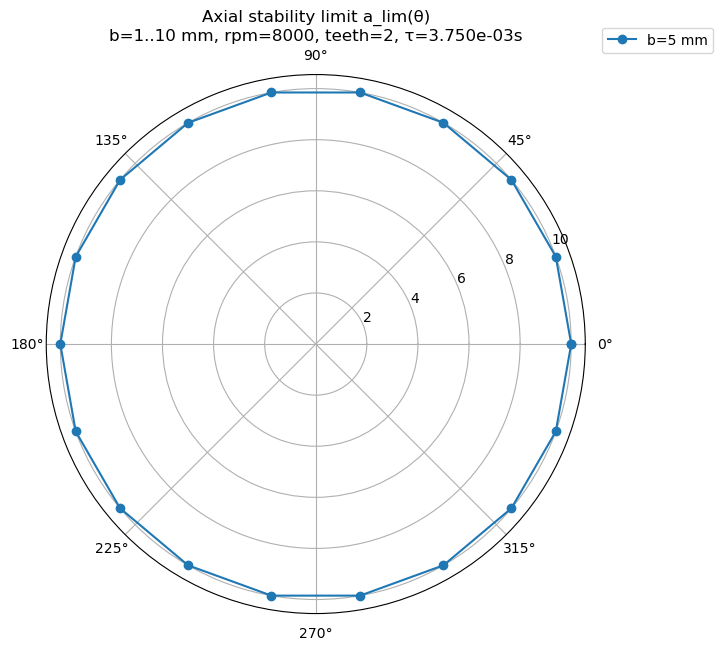

In [23]:
# ============================================================
# Polar axial-limit plot:
# for each b in [1..10] mm, find a_lim(theta) where stability flips
# ============================================================

# ----- User settings
angles_deg = np.arange(0, 361, 20)         # orientation sweep
angles_rad = np.deg2rad(angles_deg)

b_sweep_mm = np.arange(5, 6)           # 1..10 mm
b_sweep = b_sweep_mm * 1e-3                # meters

print(b_sweep_mm)

# axial depth search grid (choose range/step)
a_min_mm  = 1.0
a_max_mm  = 10.0
a_step_mm = 1.0                           # finer -> more accurate but slower
a_grid = np.arange(a_min_mm, a_max_mm + 1e-12, a_step_mm) * 1e-3  # meters

# chatter classifier knobs (reuse your defaults, but you can tune)
dt = 2e-5
growth_alpha_thresh = 5.0
explode_factor = 1e4
abs_limit = 1e-2

# Optional: make simulation shorter to speed up (still “enough” cycles)
# If you want, override T inside simulate_and_classify by passing T=...
# Example: T = max(0.15, 20*tau)
T_override = max(0.15, 20.0 * tau)

def find_axial_limit_for_theta_and_b(theta_rad, b_m):
    """
    Returns:
      a_lim (m): borderline stable axial depth (largest stable a in a_grid)
      status: "all_stable" / "all_unstable" / "borderline"
    """
    # Precompute geometry once per b
    phi_st, phi_ex = compute_entry_exit_angles_downmilling_steady(b_m, D)

    last_stable_a = None
    ever_stable = False
    ever_unstable = False

    for a_m in a_grid:
        A0 = altintas_zero_order_directional_matrix(
            a=a_m, N=N_teeth,
            phi_st=phi_st, phi_ex=phi_ex,
            Ktc=Ktc, Krc=Krc
        )
        A = rotate_A(A0, theta_rad)

        stable, alpha, _ = simulate_and_classify(
            A_cut_dir=A, tau=tau,
            dt=dt, T=T_override,
            growth_alpha_thresh=growth_alpha_thresh,
            explode_factor=explode_factor,
            abs_limit=abs_limit
        )

        if stable:
            ever_stable = True
            last_stable_a = a_m
        else:
            ever_unstable = True
            # assume stability degrades as a increases; first unstable => limit found
            if last_stable_a is not None:
                return last_stable_a, "borderline"
            else:
                return a_grid[0], "all_unstable"

    # If we never became unstable up to a_max
    if ever_stable and not ever_unstable:
        return a_grid[-1], "all_stable"

    # Fallback (shouldn’t happen often)
    return (last_stable_a if last_stable_a is not None else a_grid[0]), "borderline"


# ----- Compute a_lim(theta) for each b
a_lim_map = {}     # b_mm -> array of a_lim (m) per theta
status_map = {}    # b_mm -> list of statuses per theta

for b_mm, b_m in zip(b_sweep_mm, b_sweep):
    a_lims = []
    statuses = []
    print(f"\n=== b = {b_mm} mm ===")
    for th_deg, th_rad in zip(angles_deg, angles_rad):
        a_lim, status = find_axial_limit_for_theta_and_b(th_rad, b_m)
        a_lims.append(a_lim)
        statuses.append(status)
        print(f"theta={th_deg:3d}°  a_lim={a_lim*1e3:6.2f} mm   ({status})")

    a_lim_map[b_mm] = np.array(a_lims, dtype=float)
    status_map[b_mm] = statuses


# ----- Polar plot: radius = a_lim, angle = theta
plt.figure(figsize=(7, 7))
ax = plt.subplot(111, projection='polar')

# Use theta in radians for polar
theta_plot = angles_rad

for b_mm in b_sweep_mm:
    r_mm = a_lim_map[b_mm] * 1e3  # convert to mm for plotting
    ax.plot(theta_plot, r_mm, marker='o', label=f"b={b_mm} mm")

ax.set_title(f"Axial stability limit a_lim(θ)\n"
             f"b=1..10 mm, rpm={rpm:.0f}, teeth={N_teeth}, τ={tau:.3e}s")
ax.set_rlabel_position(22.5)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))
plt.show()